In [2]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import rateslib as rl
import QuantLib as ql

import datetime
import pytz

NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
LDN_tz = pytz.timezone("Europe/London") 
UTC_tz = pytz.timezone("UTC") 

import sys
sys.path.append("../")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
from MDP.STIRFutures.STIRFutureMDP import STIRFutureMDP
from MDP.STIRFutures.STIRFutureOptionMDP import STIRFutureOptionMDP
from MDP.IRSwaps.BARCHART_STIRF.rl import BARCHART_STIRF_CURVE, plot_overnight_forward_curves
from MDP.STIRFutures.BARCHART.BarchartFetcher import BarchartFetcher

from BT.misc import ql_cal_date_range

In [4]:
bc_stirf_curve = BARCHART_STIRF_CURVE()
stirf_mdp = STIRFutureMDP(source="BARCHART_TOS_LIVE_STIRF-RL")
stirfo_mdp = STIRFutureOptionMDP(source="BARCHART_STIRFO-QL")

In [16]:
out = stirfo_mdp.get_data({
    "endpoint": "option_snapshot",
    "symbols": ["S0Z26|ATMS"],
    "timestamp": datetime.date(2026, 2, 27),
    "show_tqdm": False,
    "use_ql_calculator": True,
})
out

FETCHING SESSION TOKENS...: 100%|██████████| 3/3 [00:01<00:00,  2.20it/s]


{'S0Z26|ATMS': [QLSTIRFutureOptionPricer(_symbol='0QZ26|9700S', _right='S', _underlying_symbol='SFRZ27', _strike=97.0, _quote_timestamp=datetime.datetime(2026, 2, 27, 17, 0, tzinfo=<DstTzInfo 'America/New_York' EST-1 day, 19:00:00 STD>), _expiry_date=datetime.date(2026, 12, 16), _market_price=0.63, _model_price=0.6300000000000006, _iv_normal=0.906760196984443, _delta=0.03824927344407669, _gamma=0.9554567447434652, _vega=0.693093974738086, _theta=-0.3707356447722685, _forward=97.04, _discount=0.9723783362605756, _meta_data={'schema': 1, 'source': 'SYNTH_STRADDLE', 'symbol': '0QZ26|9700S', 'underlying_symbol': 'SFRZ27', 'legs': ['0QZ26|9700C@2026-02-27T17:00:00-05:00', '0QZ26|9700P@2026-02-27T17:00:00-05:00'], 'curve_name': 'USD-SOFR-1D-Q12xM12STIRT', 'curve_error': None, 'vendor_legs': [{'Open': 0.335, 'High': 0.335, 'Low': 0.335, 'Close': 0.335, 'Volume': 1660.0, 'Open Interest': 0.0}, {'Open': 0.295, 'High': 0.295, 'Low': 0.295, 'Close': 0.295, 'Volume': 272.0, 'Open Interest': 0.0}]}

In [17]:
p = next(iter(out.values()))[0]
print("price:", p.price())
print("iv_normal_bps:", p.iv_normal_bps())
print("delta/gamma/vega/theta:", p.delta(), p.gamma(), p.vega(), p.theta())

price: 0.63
iv_normal_bps: 90.67601969844429
delta/gamma/vega/theta: 0.03824927344407669 0.9554567447434652 0.693093974738086 -0.3707356447722685


FETCHING SESSION TOKENS...: 100%|██████████| 37/37 [00:03<00:00, 11.26it/s]


SUCCESS: `conv_tol` reached after 4 iterations (levenberg_marquardt), `f_val`: 0.005673076874133559, `time`: 0.1387s
SUCCESS: `conv_tol` reached after 4 iterations (levenberg_marquardt), `f_val`: 5628.099057829071, `time`: 0.1284s


(<Figure size 1200x800 with 1 Axes>,
 <Axes: >,
 [<matplotlib.lines.Line2D at 0x295c1842710>])

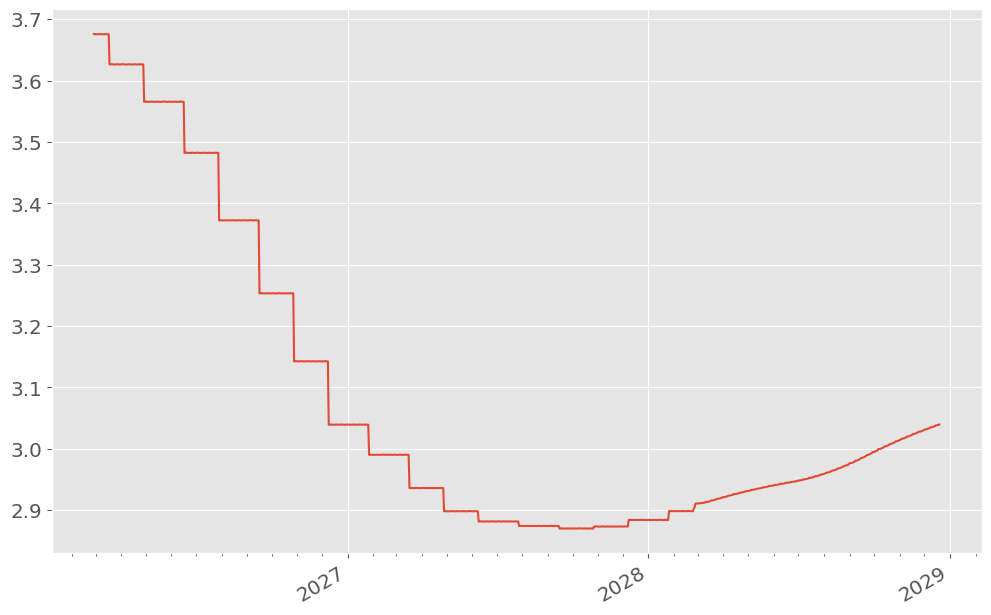

In [4]:
# ts = NY_tz.localize(datetime.datetime(2026, 2, 17, 17, 00))
# curve, solver = bc_stirf_curve.build_curve(curve_name="USD-OIS-Q8xM12", timestamp=ts, kwargs=dict(force_refresh=False))
# curve, solver = bc_stirf_curve.build_curve(curve_name="USD-SOFR-1D-Q12x3", timestamp=ts, kwargs=dict(force_refresh=True))

# timestamps = ql_cal_date_range(
#     ql.UnitedStates(ql.UnitedStates.GovernmentBond),
#     start=NY_tz.localize(datetime.datetime(2026, 2, 17, 1, 50)),
#     end=NY_tz.localize(datetime.datetime(2026, 2, 17, 17, 00)),
#     freq="1min",
# )
# timestamps = pd.date_range(NY_tz.localize(datetime.datetime(2026, 2, 17, 16, 50)), NY_tz.localize(datetime.datetime(2026, 2, 17, 17, 00)), freq="1min").to_list()

curves = bc_stirf_curve.build_curve(
    curve_name="USD-OIS-Q12xM12STIRT-SERFFX-MIX23",
    # curve_name="EUR-ESTR-NYC-Q12STIRT",
    # timestamp=LDN_tz.localize(datetime.datetime(2026, 2, 19, 17, 00)),
    timestamp=NY_tz.localize(datetime.datetime(2026, 2, 27, 17, 00)),
    # timestamp="live",
    kwargs={
        "force_refresh": True,
        # "cache_full_intraday_fetch": True,
    },
)
curves.plot("1d")

SUCCESS: `conv_tol` reached after 4 iterations (levenberg_marquardt), `f_val`: 0.008517682153055702, `time`: 0.1191s


(<Figure size 1200x800 with 1 Axes>,
 <Axes: >,
  <matplotlib.lines.Line2D at 0x295d0a76c10>])

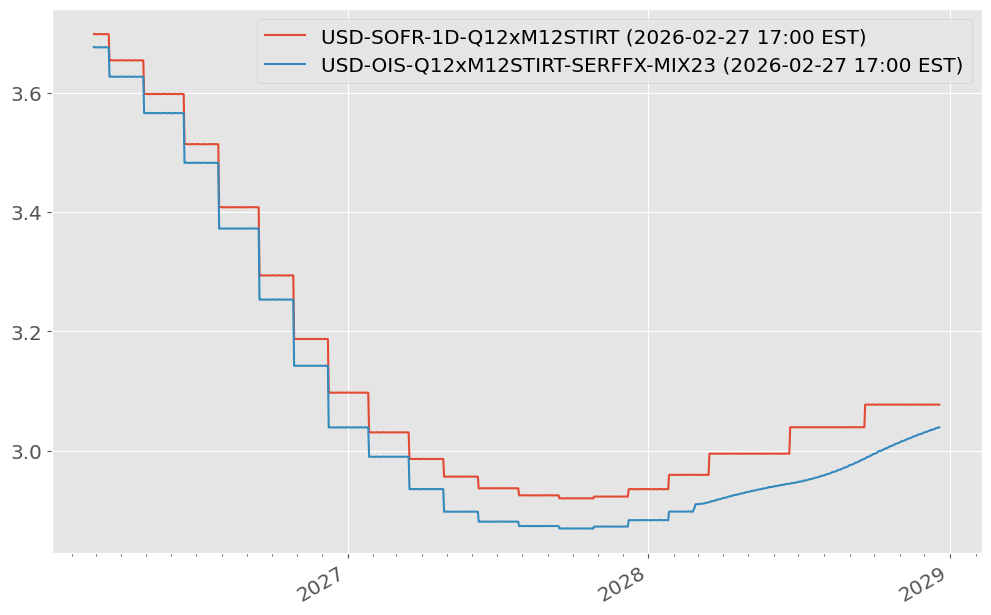

In [21]:
plot_overnight_forward_curves(
    curves=[
        bc_stirf_curve.build_curve(
            curve_name="USD-SOFR-1D-Q12xM12STIRT",
            timestamp=NY_tz.localize(datetime.datetime(2026, 2, 27, 17, 00)),
            # timestamp="live",
            # kwargs={
			# 	"force_refresh": True,
			#     "cache_full_intraday_fetch": True,
            # },
        ),
        # bc_stirf_curve.build_curve(
        #     curve_name="USD-OIS-Q12xM12STIRT-SERFFX-MIX23",
        #     timestamp=NY_tz.localize(datetime.datetime(2026, 2, 27, 17, 00)),
        # ),
        bc_stirf_curve.build_curve(
            curve_name="USD-OIS-Q12xM12STIRT-SERFFX-MIX23",
            timestamp=NY_tz.localize(datetime.datetime(2026, 2, 27, 17, 00)),
			# kwargs={
			# 	"force_refresh": True,
			# },
        ),
        # bc_stirf_curve.build_curve(
        #     curve_name="USD-OIS-Q12xM11STIRT",
        #     timestamp=NY_tz.localize(datetime.datetime(2025, 8, 1, 15, 00)),
        # ),
        # bc_stirf_curve.build_curve(
        #     curve_name="USD-OIS-Q12xM12STIRT",
        #     timestamp=NY_tz.localize(datetime.datetime(2025, 8, 1, 17, 00)),
        # ),
    ]
)

In [110]:
fomc_dated_ois = {
    "mar26": (rl.dt(2026, 3, 18), rl.dt(2026, 4, 29)),
    "apr26": (rl.dt(2026, 4, 29), rl.dt(2026, 6, 17)),
    "jun26": (rl.dt(2026, 6, 17), rl.dt(2026, 7, 29)),
    "jul26": (rl.dt(2026, 7, 29), rl.dt(2026, 9, 16)),
    "sep26": (rl.dt(2026, 9, 16), rl.dt(2026, 10, 28)),
    "oct26": (rl.dt(2026, 10, 28), rl.dt(2026, 12, 9)),
    # "dec26": (rl.dt(2026, 12, 9), rl.dt(2027, 1, 27)),
}

ecb_dated_ois = {
    "mar26": (rl.dt(2026, 3, 25), rl.dt(2026, 5, 6)),
    "may26": (rl.dt(2026, 5, 6),  rl.dt(2026, 6, 17)),
    "jun26": (rl.dt(2026, 6, 17), rl.dt(2026, 7, 29)),
    "jul26": (rl.dt(2026, 7, 29), rl.dt(2026, 9, 16)),
    "sep26": (rl.dt(2026, 9, 16), rl.dt(2026, 11, 4)),
    "nov26": (rl.dt(2026, 11, 4), rl.dt(2026, 12, 23)),
}


def build_meeting_dated_ois(meeting: str, meeting_dates: dict, rl_curve: rl.Curve, risk=None, notional=None, rl_irs_swap_kargs={}):
    assert risk is not None or notional is not None, "Must pass in `risk` or `notional`"

    if risk is not None:
        unit_delta = rl.IRS(
            effective=meeting_dates[meeting][0], termination=meeting_dates[meeting][1], spec="usd_irs_lt_2y", curves=rl_curve, notional=1
        ).analytic_delta(rl_curve)
        notional = risk / unit_delta

    fomc_swap = rl.IRS(
        effective=meeting_dates[meeting][0], termination=meeting_dates[meeting][1], spec="usd_irs_lt_2y", curves=rl_curve, notional=notional, **rl_irs_swap_kargs
    )
    return fomc_swap



meeting_dates = fomc_dated_ois
for key in meeting_dates.keys():
    print(key, build_meeting_dated_ois(meeting=key, meeting_dates=meeting_dates, rl_curve=curves, notional=1).rate().real)

# for key in ecb_dated_ois.keys():
#     print(key, build_ecb_ois(meeting=key, rl_curve=curves, notional=1).rate().real)

mar26 3.642749968539606
apr26 3.5951974838899146
jun26 3.511426176876371
jul26 3.3988648325850006
sep26 3.274920812397474
oct26 3.1876942095956378


In [123]:
mdp = STIRFutureMDP(source="BARCHART_STIRF-RL")

# must be timezone-aware
chi_tz = pytz.timezone("America/Chicago")
ts = chi_tz.localize(datetime.datetime(2026, 2, 20, 17, 00))

mdp.get_data(
    {
        "symbols": ["SERCM1"],
        # "timestamp": ts,
        "timestamp": "live",
        # "force_refresh": True,
        # "cache_full_intraday_fetch": True,
    }
)

FETCHING SESSION TOKENS...: 100%|██████████| 2/2 [00:00<00:00,  2.00it/s]


{'SERCM1': [RLSTIRFuturePricer(_curve='USD-SOFR-1D', _rl_stirf_id='SR1G26', _reference_date=datetime.date(2026, 2, 27), _effective_date=datetime.date(2026, 2, 2), _maturity_date=datetime.date(2026, 3, 2), _price=96.335, _rate=3.6650000000000063, _contracts=1, _notional=1000000, _meta_data={'symbol': 'SR1G26', 'price': 96.335, 'timestamp': '2026-02-27T15:00:57.593990+00:00', 'schema': 1, 'fixings': USD-SOFR-1D
  2018-04-02    1.80
  2018-04-03    1.83
  2018-04-04    1.74
  2018-04-05    1.75
  2018-04-06    1.75
                ... 
  2026-02-20    3.66
  2026-02-23    3.66
  2026-02-24    3.67
  2026-02-25    3.67
  2026-02-26    3.67
  Name: Fixing, Length: 1974, dtype: float64})]}

In [32]:
bcf = BarchartFetcher()

# USD/CAD FX Forward Tickers

dollar_cad_on_fwd = "USDCAD.O"        # Overnight
dollar_cad_tom_fwd = "USDCAD.A"       # Tomorrow
dollar_cad_spot_fwd = "USDCAD.S"      # Spot
dollar_cad_1w_fwd = "USDCAD.B"        # 1-Week
dollar_cad_2w_fwd = "USDCAD.C"        # 2-Week
dollar_cad_3w_fwd = "USDCAD.D"        # 3-Week
dollar_cad_1m_fwd = "USDCAD.E"        # 1-Month
dollar_cad_2m_fwd = "USDCAD.G"        # 2-Month
dollar_cad_3m_fwd = "USDCAD.H"        # 3-Month
dollar_cad_4m_fwd = "USDCAD.J"        # 4-Month
dollar_cad_5m_fwd = "USDCAD.K"        # 5-Month
dollar_cad_6m_fwd = "USDCAD.M"        # 6-Month
dollar_cad_7m_fwd = "USDCAD.N"        # 7-Month
dollar_cad_8m_fwd = "USDCAD.Q"        # 8-Month
dollar_cad_9m_fwd = "USDCAD.U"        # 9-Month
dollar_cad_10m_fwd = "USDCAD.V"       # 10-Month
dollar_cad_11m_fwd = "USDCAD.X"       # 11-Month
dollar_cad_1y_fwd = "USDCAD.1"        # 1-Year
dollar_cad_2y_fwd = "USDCAD.2"        # 2-Year
dollar_cad_3y_fwd = "USDCAD.3"        # 3-Year


df = bcf.barchart_timeseries_api(
    barchart_symbols=[dollar_cad_1w_fwd],
    start_date=NY_tz.localize(datetime.datetime(2026, 2, 17, 7, 00)),
    end_date=NY_tz.localize(datetime.datetime(2026, 2, 17, 17, 00)),
    interval=1,
)[dollar_cad_1w_fwd]

df

FETCHING INTRADAY DATA FROM BARCHART...: 100%|██████████| 1/1 [00:00<00:00,  2.18it/s]


,Open,High,Low,Close,Volume
Date,,,,,
2026-02-17 07:00:00-05:00,-3.9925,-3.9925,-3.9925,-3.9925,0
2026-02-17 07:01:00-05:00,-3.9925,-3.9925,-3.9925,-3.9925,0
2026-02-17 07:02:00-05:00,-3.9925,-3.9925,-3.9930,-3.9930,0
2026-02-17 07:03:00-05:00,-3.9930,-3.9930,-3.9930,-3.9930,0
2026-02-17 07:04:00-05:00,-3.9930,-3.9930,-3.9930,-3.9930,0
...,...,...,...,...,...
2026-02-17 16:46:00-05:00,-3.9940,-3.9940,-3.9940,-3.9940,0
2026-02-17 16:47:00-05:00,-3.9940,-3.9940,-3.9940,-3.9940,0
2026-02-17 16:48:00-05:00,-3.9940,-3.9940,-3.9940,-3.9940,0


FETCHING SESSION TOKENS...: 100%|██████████| 13/13 [00:01<00:00, 10.58it/s]


SUCCESS: `conv_tol` reached after 4 iterations (levenberg_marquardt), `f_val`: 0.03772044499941412, `time`: 0.0196s


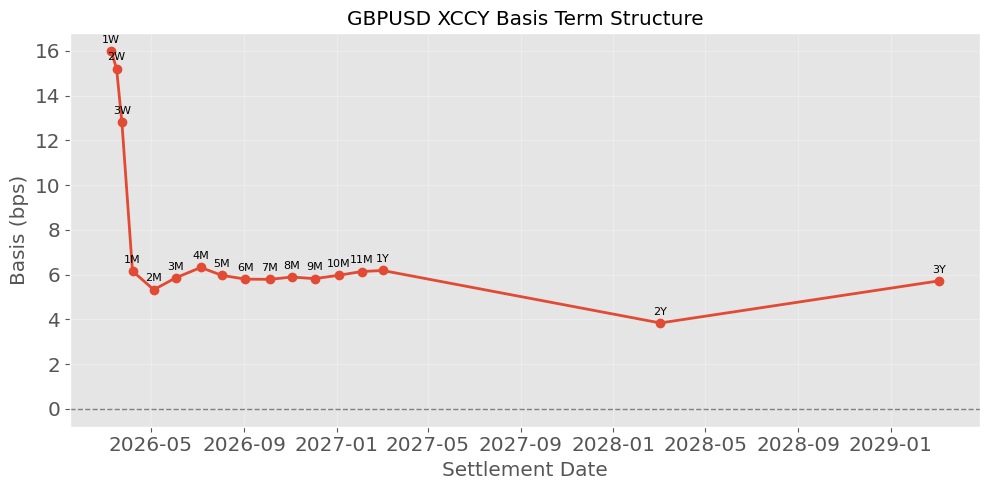

,tenor,settlement_date,basis_bps
3,1W,2026-03-10,15.990174
4,2W,2026-03-17,15.205812
5,3W,2026-03-24,12.812502
6,1M,2026-04-07,6.159049
7,2M,2026-05-05,5.326342
8,3M,2026-06-03,5.857443
9,4M,2026-07-06,6.320696
10,5M,2026-08-03,5.967084
11,6M,2026-09-03,5.798686
12,7M,2026-10-05,5.789126


In [11]:
from MDP.STIRFutures.FXForwardMDP import FXForwardMDP

mdp = FXForwardMDP(source="BARCHART_FXFWD-RL")

req = {
    "symbols": ["GBPUSD"],  # full O..3Y strip
    "timestamp": LDN_tz.localize(datetime.datetime(2026, 2, 27, 17, 00)),  
    # "curve_profile_key": "eurusd_sofr_estr_nyc",  
    "force_refresh": False,
    "window_minutes": 1,
}
out = mdp.get_data(req)

strip = next(iter(out.values())) 

rows = []
for p in strip:
    rows.append(
        {
            "tenor": p.tenor(),
            "symbol": p.symbol(),
            "settlement_date": p.settlement_date(),
            "basis_bps": p.basis_bps(),
        }
    )

df = pd.DataFrame(rows).sort_values("settlement_date")

# keep only calibrated tenors (O/A/S are typically None by design)
basis_df = df.dropna(subset=["basis_bps"]).copy()

if basis_df.empty:
    raise RuntimeError(f"No basis points available. curve_error={strip[0].meta().get('curve_error')}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(basis_df["settlement_date"], basis_df["basis_bps"], marker="o", lw=2)
ax.axhline(0.0, color="gray", lw=1, ls="--")
ax.set_title(f"{next(iter(out.keys()))} XCCY Basis Term Structure")
ax.set_xlabel("Settlement Date")
ax.set_ylabel("Basis (bps)")
ax.grid(alpha=0.3)

# optional: annotate tenor labels
for _, r in basis_df.iterrows():
    ax.annotate(r["tenor"], (r["settlement_date"], r["basis_bps"]), textcoords="offset points", xytext=(0, 6), ha="center", fontsize=8)

plt.tight_layout()
plt.show()

basis_df[["tenor", "settlement_date", "basis_bps"]]

In [34]:
out

{'EURUSD': [RLFXForwardPricer(_pair='EURUSD', _symbol='EURUSD.O', _tenor='ON', _settlement_date=datetime.date(2026, 2, 18), _quote_timestamp=datetime.datetime(2026, 2, 17, 17, 0, tzinfo=datetime.timezone.utc), _spot=1.18296, _points_raw=0.58, _points_decimal=5.7999999999999994e-05, _forward_rate=1.183018, _basis_bps=None, _fx_rates=<rl.FXRates:[eur,usd] at 0x295c16bacf0>, _fx_forwards=<rl.FXForwards:[eur,usd] at 0x295c16ba900>, _meta_data={'schema': 1, 'source': 'BARCHART_FXFWD-RL', 'symbol': 'EURUSD.O', 'pair': 'EURUSD', 'suffix': 'O', 'tenor': 'ON', 'spot_symbol': '^EURUSD', 'spot_lag_bdays': 2, 'settlement_calendar': 'nyc,tgt', 'curve_profile_key': 'eurusd_sofr_estr_ldn', 'curve_names': {'EUR': 'EUR-ESTR-LONDON-Q12STIRT', 'USD': 'USD-SOFR-1D-Q12xM12STIRT'}, 'curve_error': None, 'spot_timestamp': datetime.datetime(2026, 2, 17, 17, 0, tzinfo=datetime.timezone.utc), 'quote_timestamp': datetime.datetime(2026, 2, 17, 17, 0, tzinfo=datetime.timezone.utc)}),
  RLFXForwardPricer(_pair='EURU